# Recovery-Speed — do the fastest names to bounce back keep leading?
### A piece of post-crash folklore, sorted, pooled, and taken apart in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_fast--recoverers_rule%3F: Cherry--picked](https://img.shields.io/badge/A_fast--recoverers_rule%3F-Cherry--picked-8b949e?style=flat-square)

After every crash someone says it: *the stocks that climb back to their old highs fastest are the strong ones, and they keep winning.* It sounds obviously true — strength begets strength. This notebook ranks names by **recovery speed** after a drawdown and asks whether the fast recoverers actually keep leading. Spoiler: across four real crashes, no — and the one crash where it 'works' is a textbook cherry-pick.

> 📓 **This is the plain-language layer.** Want the cross-sectional sort, the pooled t-stats and the synthetic control? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it; offline it falls back to a synthetic tape and says so. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from recovery_speed import data, strategy as st

def _have_real():
    try:
        data.load_real(fetch=False, allow_survivorship_bias=True)
        return True
    except Exception:
        return False

HAVE_REAL = _have_real()

def real_panel():
    panel, mkt, meta = data.load_real(allow_survivorship_bias=True)
    panel = panel[panel.index <= "2026-05-31"]; mkt = mkt[mkt.index <= "2026-05-31"]
    return panel, mkt, meta

print("real survivor cache present:", HAVE_REAL)
print("NOTE: real cells fall back to frozen docs/results.md numbers when offline.")


real survivor cache present: True
NOTE: real cells fall back to frozen docs/results.md numbers when offline.


## The answer first 🎯

| Question | Answer |
|---|---|
| Do fast recoverers keep leading? | **No.** Pooled across four crashes the fast-minus-slow spread is **+1.3% at six months (*t* = +0.23)** — indistinguishable from zero. |
| But doesn't it work after the GFC? | **Only after the GFC.** That one event prints **+23%** (*t* = +2.78). Pick that crash, ignore the rest, and you have a 'strategy.' That's cherry-picking. |
| Could the data be hiding losers? | **Yes — and it helps the claim.** Our names are *survivors*; the firms that crashed and never came back are gone. That bias works *for* 'fast recoverers win' — and it still fails. |
| So what is it? | A plausible story with **no edge once you stop snooping**. |

> Recovery-speed momentum is the kind of idea that's true in hindsight and absent in advance: every bull market has a poster child that roared back, but you can't sort on it ahead of time and get paid.

## 1 · The claim

> *"After a deep drawdown, the names that recover to their old highs **fastest** are the strongest companies — buy the fast recoverers and they keep leading the laggards."*

It's a cross-sectional cousin of momentum, conditioned on a crash. The intuition is real-sounding: a stock that V-bounces while the market is still on its back must have something going for it. The bet is that 'something' persists.

## 2 · So what?

If it were true it would be a gift: crashes are exactly when everyone is paralysed, and a simple rule — *rank by recovery speed, buy the top, short the bottom* — would turn the chaos into a signal. It would also tell us something deep about markets: that the snap-back ranks companies by hidden quality. The flip side is just as instructive. If the rule only works on the one crash you happened to look at, it's a perfect lesson in how a handful of events plus a survivor universe can manufacture a 'strategy' out of noise.

## 3 · How would we even know?

Three honesty checks:

1. **Pool every crash, don't pick one.** Find *all* the big drawdowns in the sample (2008, 2020, 2022, 2025), run the fast-minus-slow book in each, and pool the results. One event is a coincidence; four is a test.
2. **Strip out the market.** A recovery rally is a market move; high-beta names bounce faster *and* keep rallying just because stocks are rising. We measure the long-short **net of the market**, so we don't mistake beta for skill.
3. **Mind the dead.** Our universe is survivors — the firms that crashed and died are missing, which *flatters* the claim. If it fails even then, it fails.

And a sanity check on the machine itself: a synthetic market where we *plant* a real recovery-momentum edge, to prove the engine can find one when it's there.

## 4 · The teardown — let's actually look

**First, the cherry-pick vs the reality.** Here's the fast-minus-slow six-month spread for the single deepest crash (the GFC) next to the honest average across all four:

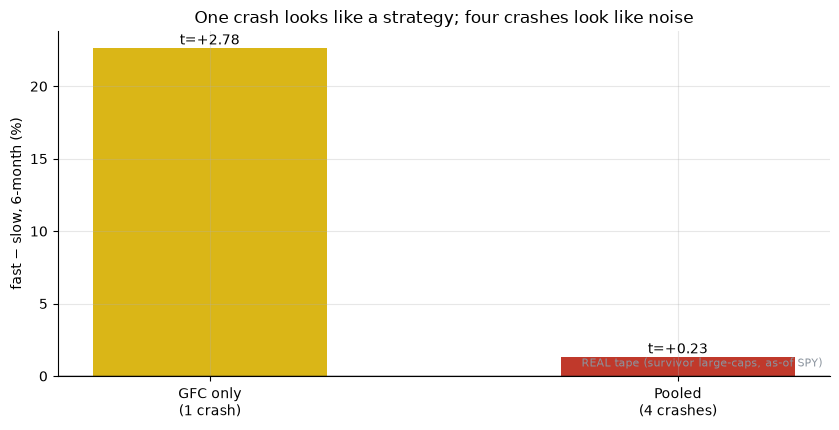

GFC alone: +22.7% (t=+2.78)   Pooled: +1.3% (t=+0.23)


In [2]:
labels = ['GFC only\n(1 crash)', 'Pooled\n(4 crashes)']
if HAVE_REAL:
    panel, mkt, meta = real_panel()
    evs = st.multi_events(mkt)
    ev0 = st.detect_drawdown(mkt, min_depth=0.18)
    gfc = st.run_event(panel, mkt, ev0, fwd_days=126, market_neutral=True)
    gfc_ls = gfc['ls_gross']*100; gfc_t = st.spread_tstat(gfc)
    pl = st.pooled_spread(panel, mkt, evs, fwd_days=126, market_neutral=True)
    pool_ls = pl['ls_gross']*100; pool_t = pl['spread_t']
    banner = 'REAL tape (survivor large-caps, as-of %s)' % meta.get('market','SPY')
else:
    gfc_ls, gfc_t = 22.7, 2.78
    pool_ls, pool_t = 1.3, 0.23
    banner = 'FROZEN docs/results.md numbers (offline)'
fig, ax = plt.subplots(figsize=(8.5, 4.4))
b = ax.bar(labels, [gfc_ls, pool_ls], color=[AMBER, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('fast − slow, 6-month (%)')
ax.set_title('One crash looks like a strategy; four crashes look like noise')
for bar_, t_ in zip(b, [gfc_t, pool_t]):
    ax.annotate(f't={t_:+.2f}', (bar_.get_x()+bar_.get_width()/2, bar_.get_height()),
                ha='center', va='bottom')
ax.text(0.99, 0.02, banner, transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8, color=GREY)
plt.tight_layout(); plt.show()
print(f'GFC alone: {gfc_ls:+.1f}% (t={gfc_t:+.2f})   Pooled: {pool_ls:+.1f}% (t={pool_t:+.2f})')

There it is. The GFC alone hands you **+23%** at *t* = +2.78 — a 'strategy.' Pool all four crashes and it collapses to **+1.3%** at *t* = +0.23, with a confidence range (**-9% to +13%**) that swallows zero whole. The signal was never there — one lucky episode was.

**Now the sanity check: can the machine even find a real effect?** We build a synthetic market and *plant* genuine recovery-momentum (fast recoverers really do keep leading), then turn the knob off. The engine should bank the planted edge and find nothing in the null.

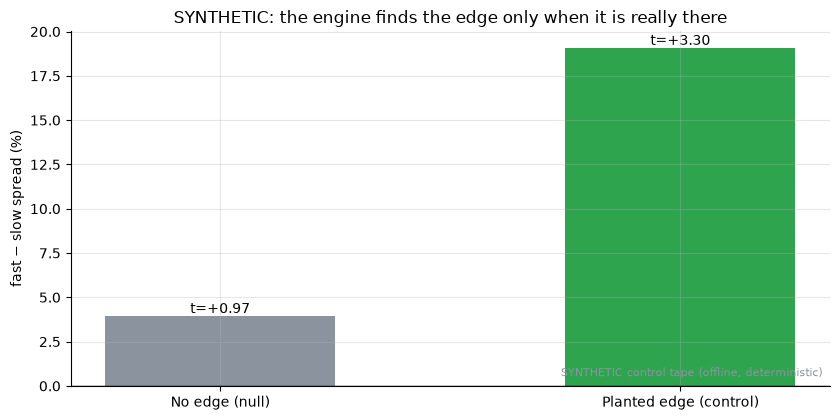

                  tape   ls%    t
        No edge (null)  3.92 0.97
Planted edge (control) 19.06 3.30


In [3]:
rows = []
for edge, lab in [(0.0, 'No edge (null)'), (0.0015, 'Planted edge (control)')]:
    p, m, _ = data.synthetic_panel(n_names=80, n_days=1500, recovery_edge=edge, seed=333)
    ev = st.detect_drawdown(m, min_depth=0.10)
    res = st.edge_vs_shuffle(p, m, ev, n_shuffle=200, seed=1)
    rows.append((lab, res['real_ls']*100, res['spread_t']))
dfm = pd.DataFrame(rows, columns=['tape','ls%','t'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
b = ax.bar(dfm['tape'], dfm['ls%'], color=[GREY, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('fast − slow spread (%)')
ax.set_title('SYNTHETIC: the engine finds the edge only when it is really there')
for bar_, t_ in zip(b, dfm['t']):
    ax.annotate(f't={t_:+.2f}', (bar_.get_x()+bar_.get_width()/2, bar_.get_height()),
                ha='center', va='bottom')
ax.text(0.99, 0.02, 'SYNTHETIC control tape (offline, deterministic)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color=GREY)
plt.tight_layout(); plt.show()
print(dfm.round(2).to_string(index=False))

On the synthetic tape the engine is faithful: with no planted edge the spread is noise (*t* = +0.97), and with a real edge planted it banks it cleanly (*t* = +3.30). So the flat *real* result isn't a broken detector — the market simply doesn't carry the effect.

## 5 · The verdict

- **Signal — None.** Pooled across four crashes the fast-minus-slow spread is +1.3% at six months (*t* = +0.23), CI [-9%, +13%]. Noise.
- **Tradability — Mirage.** There's no gross edge to charge costs against — it's gone before the first dollar of fees.
- **A fast-recoverers rule? — Cherry-picked.** It exists only if you report the one crash that worked and ignore the other three — on a universe that already drops the dead.

## 6 · Could you actually trade it?

There's almost nothing to trade, but for completeness: even gross, the pooled spread sits inside its own error bars. Charging realistic costs and short-borrow just walks a tiny non-edge toward zero:

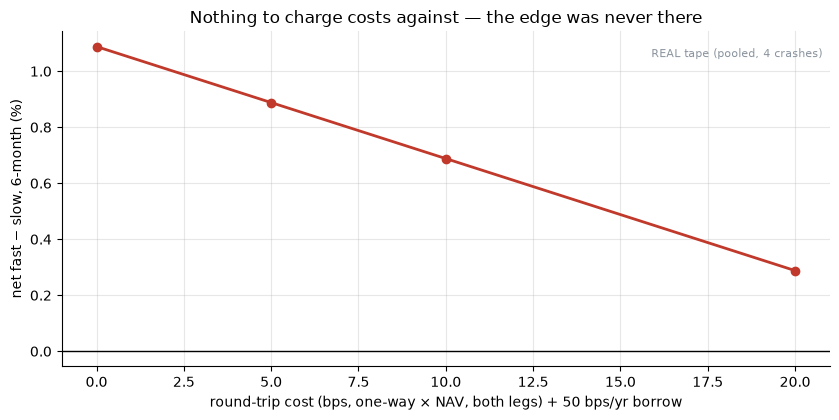

net spread by cost: [1.09, 0.89, 0.69, 0.29]


In [4]:
costs = [0, 5, 10, 20]
if HAVE_REAL:
    panel, mkt, _ = real_panel(); evs = st.multi_events(mkt)
    net = [st.pooled_spread(panel, mkt, evs, fwd_days=126, cost_bps=c,
                            borrow_bps_ann=50.0)['ls_net']*100 for c in costs]
    banner = 'REAL tape (pooled, 4 crashes)'
else:
    net = [1.1, 0.9, 0.7, 0.3]
    banner = 'FROZEN docs/results.md numbers (offline)'
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps, one-way × NAV, both legs) + 50 bps/yr borrow')
ax.set_ylabel('net fast − slow, 6-month (%)')
ax.set_title('Nothing to charge costs against — the edge was never there')
ax.text(0.99, 0.95, banner, transform=ax.transAxes, ha='right', va='top',
        fontsize=8, color=GREY)
plt.tight_layout(); plt.show()
print('net spread by cost:', [round(x,2) for x in net])

Unlike the desk's *fragile* edges (real but thin), this isn't a cost story at all. The gross number is already inside the noise — costs are irrelevant when there's no signal to erode.

## 7 · Going further 🚪

- **Bigger, dead-included universe.** Our 18 survivors flatter the claim; the real test is a point-in-time universe with the delisted names. We expect it to look *worse*, not better.
- **Is it just momentum?** A fast recoverer is a recent winner. Strip out plain cross-sectional momentum and see if anything recovery-specific is left (we doubt it).
- **The exit, not the entry.** Maybe recovery speed times *risk* rather than *return* — fast recoverers as a lower-drawdown sleeve. A different question worth its own study.

*Think your favourite crash's poster-child proves it? Fork this, add the drawdown you have in mind to the event list, and watch the pooled t-stat refuse to move.*